<a href="https://colab.research.google.com/github/ackuyucu/Ekoloji_Lab/blob/main/Dogal_secilim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- MODEL 1: Seçilim Yok ---


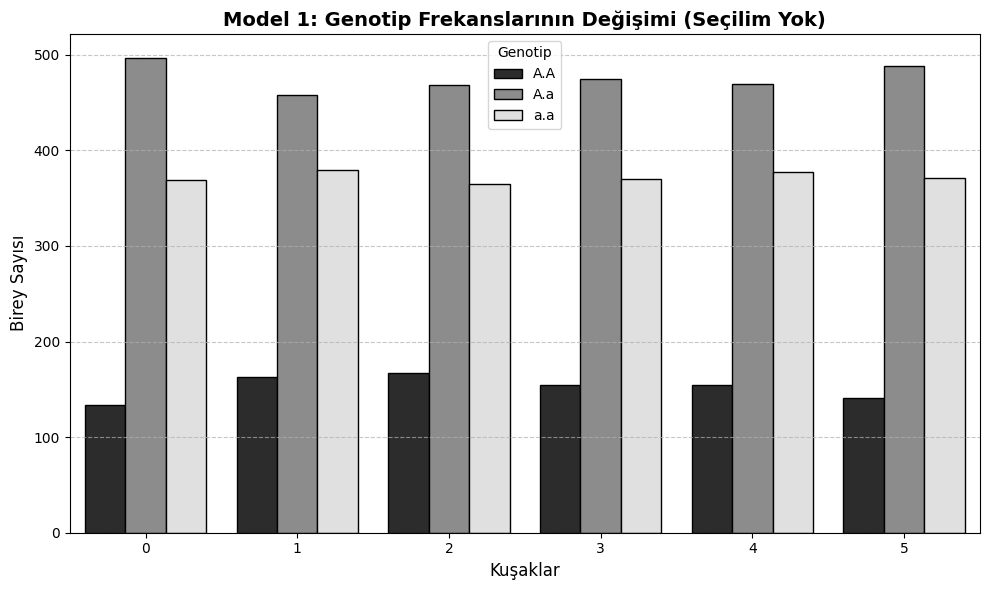


--- MODEL 2: Endüstri Devrimi Öncesi (Koyu 'A' alleline karşı seçilim) ---


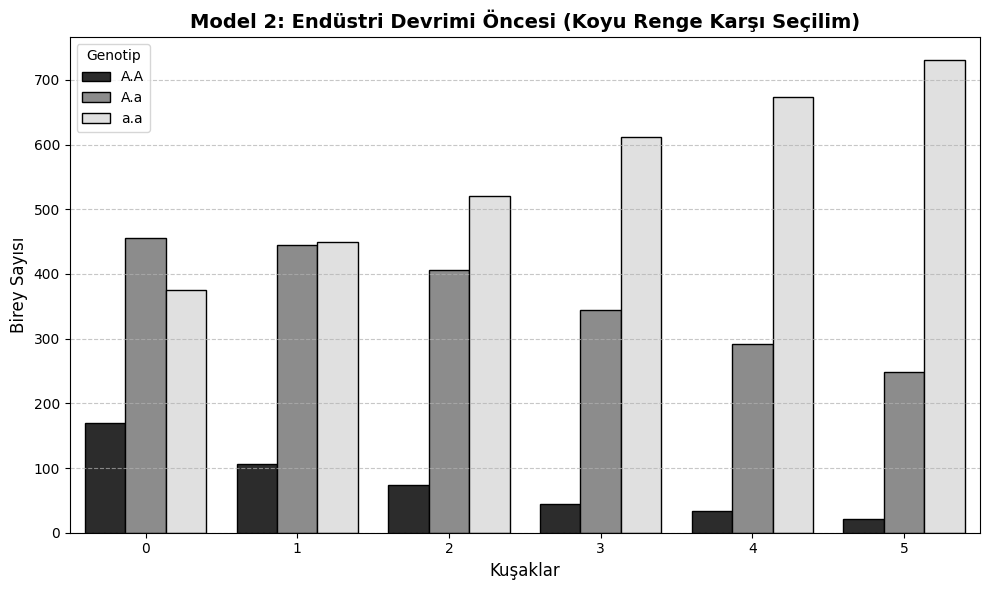


--- MODEL 3: Endüstri Devrimi Sonrası (Açık 'a' alleline karşı seçilim) ---


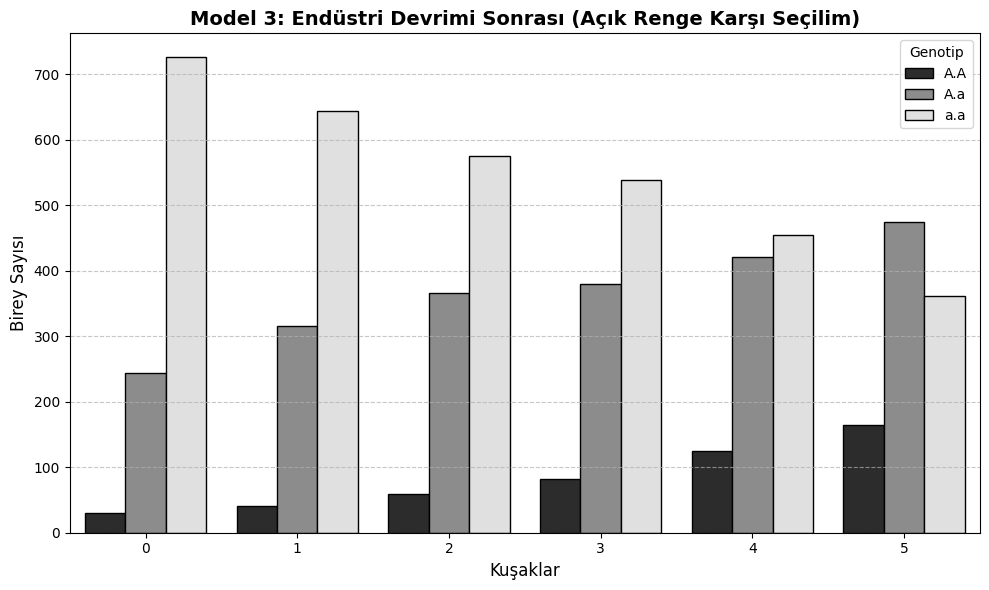


Kontenjans Tablosu (0. Kuşak vs 5. Kuşak Allel Sayıları - [A, a]):
[[ 304 1696]
 [ 804 1196]]

Ki-Kare Testi Sonuçları:
Ki-kare İstatistiği: 310.8301
p-değeri: 1.4401e-69


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Tekrarlanabilirlik için
np.random.seed(14)

def primary(sample_size, freq_A=0.1):
    """İlk kuşağı (0. Kuşak) oluşturur."""
    freq_a = 1 - freq_A

    # Vektörize edilmiş rastgele allel seçimi
    alleles1 = np.random.choice(["A", "a"], size=sample_size, p=[freq_A, freq_a])
    alleles2 = np.random.choice(["A", "a"], size=sample_size, p=[freq_A, freq_a])

    # Allelleri birleştirme ve standartlaştırma ("a.A" -> "A.a")
    inds = [f"{a1}.{a2}" if f"{a1}.{a2}" != "a.A" else "A.a" for a1, a2 in zip(alleles1, alleles2)]

    return pd.DataFrame({"Inds": inds, "Generation": 0})

def selection(sample_size, freq_A=0.1, sel_coef=[1, 1, 1], generations=range(1, 6)):
    """Belirli seçilim katsayıları altında kuşakları simüle eder."""
    # Başlangıç populasyonu
    pop_list = [primary(sample_size, freq_A)]

    for gen in generations:
        prev_gen = pop_list[-1]["Inds"].values

        # Seçilim katsayılarına göre hayatta kalanları hesaplama
        live_AA = int(round(np.sum(prev_gen == "A.A") * sel_coef[0]))
        live_Aa = int(round(np.sum(prev_gen == "A.a") * sel_coef[1]))
        live_aa = int(round(np.sum(prev_gen == "a.a") * sel_coef[2]))

        # Hayatta kalanlardan havuz oluşturma
        survivors = (["A.A"] * live_AA) + (["A.a"] * live_Aa) + (["a.a"] * live_aa)

        # Eğer hayatta kalan yoksa döngüyü kır (popülasyon yok oldu)
        if not survivors:
            print(f"Uyarı: {gen}. kuşakta popülasyon yok oldu!")
            break

        # Havuzdaki allelleri ayrıştırma
        allele_pool = [allele for ind in survivors for allele in ind.split(".")]

        # Yeni kuşağı rastgele çiftleşme ile oluşturma
        new_alleles1 = np.random.choice(allele_pool, size=sample_size, replace=True)
        new_alleles2 = np.random.choice(allele_pool, size=sample_size, replace=True)

        new_inds = [f"{a1}.{a2}" if f"{a1}.{a2}" != "a.A" else "A.a" for a1, a2 in zip(new_alleles1, new_alleles2)]

        pop_list.append(pd.DataFrame({"Inds": new_inds, "Generation": gen}))

    return pd.concat(pop_list, ignore_index=True)

def get_allele_stats(pop, generation):
    """Allel sayılarını ve frekanslarını hesaplar."""
    gen_data = pop[pop["Generation"] == generation]
    n_individuals = len(gen_data)

    count_A = (2 * np.sum(gen_data["Inds"] == "A.A")) + np.sum(gen_data["Inds"] == "A.a")
    count_a = (2 * np.sum(gen_data["Inds"] == "a.a")) + np.sum(gen_data["Inds"] == "A.a")

    total_alleles = 2 * n_individuals

    return {
        "counts": [count_A, count_a],
        "frequencies": [count_A / total_alleles, count_a / total_alleles]
    }

def plot_population(pop_data, title):
    """Fenotiplere uygun özel renklerle (koyu, orta, açık) grafiği çizer."""
    # Özel renk paleti
    phenotype_colors = {"A.A": "#2c2c2c", "A.a": "#8c8c8c", "a.a": "#e0e0e0"}

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=pop_data,
        x="Generation",
        hue="Inds",
        palette=phenotype_colors,
        edgecolor="black", # Çubukların etrafında siyah çerçeve (açık renklerin görünmesi için)
        hue_order=["A.A", "A.a", "a.a"]
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Kuşaklar", fontsize=12)
    plt.ylabel("Birey Sayısı", fontsize=12)
    plt.legend(title="Genotip")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ==========================================
# SİMÜLASYONLAR VE İSTATİSTİKSEL TESTLER
# ==========================================

print("--- MODEL 1: Seçilim Yok ---")
pop_1 = selection(sample_size=1000, freq_A=0.4, sel_coef=[1, 1, 1], generations=range(1, 6))
plot_population(pop_1, "Model 1: Genotip Frekanslarının Değişimi (Seçilim Yok)")

print("\n--- MODEL 2: Endüstri Devrimi Öncesi (Koyu 'A' alleline karşı seçilim) ---")
pop_2 = selection(sample_size=1000, freq_A=0.4, sel_coef=[0.6, 0.8, 1], generations=range(1, 6))
plot_population(pop_2, "Model 2: Endüstri Devrimi Öncesi (Koyu Renge Karşı Seçilim)")

print("\n--- MODEL 3: Endüstri Devrimi Sonrası (Açık 'a' alleline karşı seçilim) ---")
# Model 2'nin sonundaki A frekansını alma
freq_A_start_m3 = get_allele_stats(pop_2, 5)["frequencies"][0]
pop_3 = selection(sample_size=1000, freq_A=freq_A_start_m3, sel_coef=[1, 0.8, 0.6], generations=range(1, 6))
plot_population(pop_3, "Model 3: Endüstri Devrimi Sonrası (Açık Renge Karşı Seçilim)")

# İstatistiksel Test (Ki-Kare)
stats_gen0 = get_allele_stats(pop_3, 0)["counts"]
stats_gen5 = get_allele_stats(pop_3, 5)["counts"]

contingency_table = np.array([stats_gen0, stats_gen5])
print("\nKontenjans Tablosu (0. Kuşak vs 5. Kuşak Allel Sayıları - [A, a]):")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nKi-Kare Testi Sonuçları:\nKi-kare İstatistiği: {chi2:.4f}\np-değeri: {p:.4e}")

### İnteraktif Simülasyon: Kullanıcı Tanımlı Parametrelerle

Bu bölümde, başlangıç genotip frekanslarını ve seçilim katsayılarını kendiniz belirleyerek simülasyonu çalıştırabilirsiniz. Bu, farklı senaryoları keşfetmek için harika bir yoldur.

In [9]:
# @title Başlangıç Genotip Frekansları
# @markdown Lütfen frekansların toplamının 1 olmasına dikkat edin.
f_AA = 0.3 # @param {type:"number"}
f_Aa = 0.5 # @param {type:"number"}
f_aa = 0.2 # @param {type:"number"}

total_freq = f_AA + f_Aa + f_aa
if abs(total_freq - 1.0) < 1e-6:
    # Allel A frekansını hesapla
    custom_freq_A = f_AA + 0.5 * f_Aa
    print(f"Hesaplanan başlangıç A allel frekansı: {custom_freq_A:.4f}")
else:
    print(f"Hata: Genotip frekanslarının toplamı 1 olmalıdır. Girilen toplam: {total_freq}. Lütfen değerleri düzeltip hücreyi tekrar çalıştırın.")
    # Hata durumunda varsayılan bir değer atayalım ki sonraki hücreler çökmesin
    custom_freq_A = 0.55


Hesaplanan başlangıç A allel frekansı: 0.5500


In [10]:
# @title Seçilim Katsayıları
# @markdown Değerler 0 ile 1 arasında olmalıdır.
s_AA = 0.9 # @param {type:"number"}
s_Aa = 1.0 # @param {type:"number"}
s_aa = 0.7 # @param {type:"number"}

if 0 <= s_AA <= 1 and 0 <= s_Aa <= 1 and 0 <= s_aa <= 1:
    custom_sel_coef = [s_AA, s_Aa, s_aa]
    print(f"Girilen seçilim katsayıları: {custom_sel_coef}")
else:
    print("Hata: Seçilim katsayıları 0 ile 1 arasında olmalıdır. Lütfen değerleri düzeltip hücreyi tekrar çalıştırın.")
    # Hata durumunda varsayılan bir değer atayalım
    custom_sel_coef = [1.0, 1.0, 1.0]


Girilen seçilim katsayıları: [0.9, 1.0, 0.7]


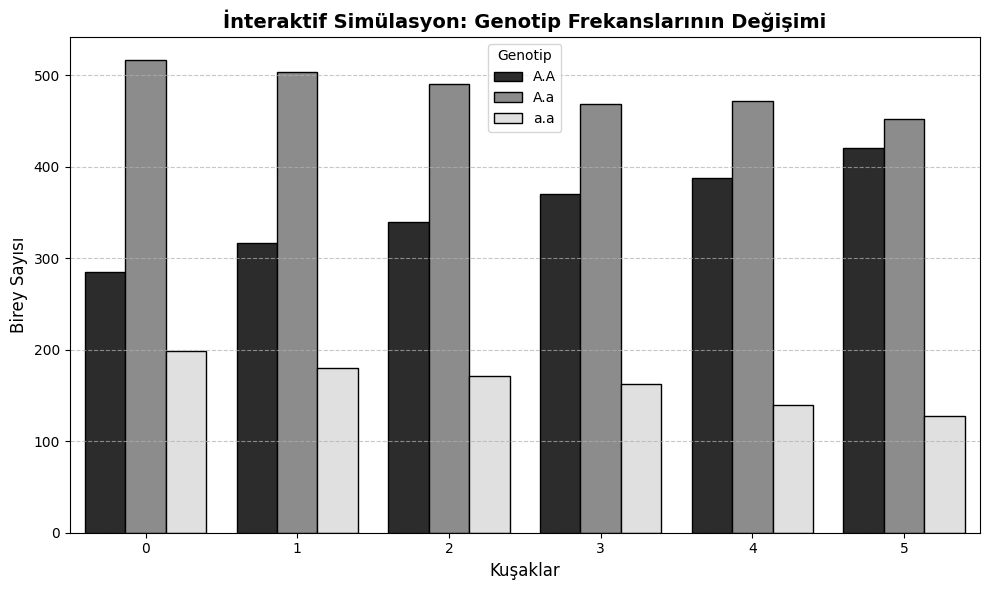

In [11]:
# Simülasyonu çalıştır
custom_pop_data = selection(sample_size=1000, freq_A=custom_freq_A, sel_coef=custom_sel_coef, generations=range(1, 6))

# Sonuçları çizdir
plot_population(custom_pop_data, "İnteraktif Simülasyon: Genotip Frekanslarının Değişimi")